# Figure 2 – PySPI vs skarf cognition prediction

## 1. Load Dependencies and Styles

In [1]:
import itertools
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map
import arfcexp.hcp
from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS

pd.options.display.precision = 4

PROJECT_ROOT = Path(os.environ["PROJECT_ROOT"]).resolve()
STYLE_PATH = os.environ["MPL_STYLE"]
plt.style.use(STYLE_PATH)

PLOT_DIR = PROJECT_ROOT / "results/poster_figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

PLOTW, PLOTH = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

TARGET = "Cognition"
TOPK_PER_CATEGORY = 2
LAG_ORDER = [0, 1]
lag_styles = {0: {"alpha": 0.85, "hatch": ""}, 1: {"alpha": 0.45, "hatch": "//"}}
NULL_BAND_COLOR = "#6c757d"
BASELINE_BAND_COLOR = "#d95f02"
NULL_BAND_ALPHA = 0.18
BASELINE_BAND_ALPHA = 0.22
METRIC_CONFIGS = {
    "r2_test": {"label": "$R^2$", "suffix": "r2"},
    "corr_test": {"label": "Pearson correlation ($r$)", "suffix": "corr"},
}
OUTLIER_PROPS = dict(
    marker="o",
    markerfacecolor="none",
    markeredgecolor="gray",
    markersize=1.5,
    alpha=0.7,
    linestyle="none",
)


def load_results(result_dir: Path) -> pd.DataFrame:
    paths = sorted(result_dir.rglob("results.json"))
    if not paths:
        raise FileNotFoundError(f"No results.json files found under {result_dir}")
    return pd.concat(pd.read_json(path, lines=True) for path in paths)


def add_iqr_band(ax, q25: float, q75: float, color: str, alpha: float = 0.2, label: str | None = None, zorder: float = 0.1):
    span = ax.axhspan(q25, q75, color=color, alpha=alpha, zorder=zorder, linewidth=0)
    if label:
        span.set_label(label)
    return span


def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0


def format_label(base_label: str, values: np.ndarray, null_p: float, baseline_p: float, bonferroni_factor: int, baseline_score: float) -> str:
    null_sig = get_significance(null_p * bonferroni_factor)
    if not null_sig:
        prefix = "(·)"
    else:
        baseline_sig = get_significance(baseline_p * bonferroni_factor)
        if baseline_sig:
            prefix = "(<)" if np.median(values) < baseline_score else "(>)"
        else:
            prefix = "(~)"
    return f"{prefix} {base_label}"


print("PROJECT_ROOT:", PROJECT_ROOT)
print("Matplotlib style:", STYLE_PATH)
print("Poster output dir:", PLOT_DIR)

PROJECT_ROOT: /home/aerkent/skarf-experiments
Matplotlib style: /home/aerkent/skarf-experiments/resources/clane.mplstyle
Poster output dir: /home/aerkent/skarf-experiments/results/poster_figures


In [2]:
# Load degenerate matrix lookup
degenerate_lookup_path = PROJECT_ROOT / "resources/matrix_degenerate_lookup.json"
degenerate_lookup = pd.read_json(degenerate_lookup_path, typ="series")
degenerate_keys = set(degenerate_lookup[degenerate_lookup].index)
print(f"Degenerate combos: {degenerate_keys}")

Degenerate combos: {'pyspi__lmfit_Lasso', 'pyspi__bary_euclidean_mean'}


## 2. Ingest PySPI Cognition Scores

In [3]:
spi_list_dir = PROJECT_ROOT / "resources/spi_lists"
pyspi_full_dir = PROJECT_ROOT / "results/hcp_1200_pyspi_behav_prediction_factor_full"
pyspi_perm_dir = PROJECT_ROOT / "results/hcp_1200_pyspi_behav_prediction_perm_test"
pyspi_baseline_dir = PROJECT_ROOT / "results/hcp_1200_pyspi_behav_prediction_all_targets_cov"

perm_results = load_results(pyspi_perm_dir)
baseline_results = load_results(pyspi_baseline_dir)
pyspi_results = load_results(pyspi_full_dir)
pyspi_results = pyspi_results[~pyspi_results["spi"].apply(lambda s: f"pyspi__{s}" in degenerate_keys)].copy()

set_cache_dir(spi_list_dir)
spi_config_map, _ = load_spi_config_map()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()
spi_id_map = {spi: idx for idx, spi in enumerate(spi_list, start=1)}

spi_table = pd.DataFrame.from_records(
    [
        {
            "spi": spi,
            "category": config["module_name"].split(".")[-1],
            "identifier": spi.split("_")[0],
        }
        for spi, config in spi_config_map.items()
        if spi in spi_list
    ]
)
spi_table["spi"] = pd.Categorical(spi_table["spi"], categories=spi_list, ordered=True)
category_levels = sorted(spi_table["category"].unique())
spi_table["category"] = pd.Categorical(spi_table["category"], categories=category_levels, ordered=True)
identifier_levels = [id_ for id_ in spi_table["identifier"].unique()]
spi_table["identifier"] = pd.Categorical(spi_table["identifier"], categories=identifier_levels, ordered=True)

pyspi_results["spi"] = pd.Categorical(pyspi_results["spi"], categories=spi_list, ordered=True)
pyspi_results = spi_table.merge(pyspi_results, on="spi", how="right")
pyspi_results = pyspi_results.dropna(subset=["spi"])
pyspi_cognition_base = pyspi_results.loc[pyspi_results["target"] == TARGET].copy()
pyspi_cognition_base["category"] = pd.Categorical(
    pyspi_cognition_base["category"], categories=category_levels, ordered=True
)
pyspi_cognition_base["identifier"] = pd.Categorical(
    pyspi_cognition_base["identifier"], categories=identifier_levels, ordered=True
)

pyspi_categories = list(pyspi_cognition_base["category"].cat.categories)
pyspi_category_colors = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(pyspi_categories)
}

print("Loaded PySPI tables with", len(pyspi_cognition_base), "rows for target", TARGET)


Loaded PySPI tables with 2920 rows for target Cognition


## 3. Ingest skarf Cognition Scores

In [4]:
skarf_full_dir = PROJECT_ROOT / "results/hcp_1200_skarf_behav_prediction_factor_full"
skarf_results = load_results(skarf_full_dir)
skarf_results = skarf_results[~skarf_results["func"].apply(lambda f: f"skarf__{f}" in degenerate_keys)].copy()
skarf_results["func"] = pd.Categorical(
    skarf_results["func"], categories=AVAILABLE_SKARF_FUNCS, ordered=True
)
skarf_results = skarf_results.dropna(subset=["func"])
skarf_cognition_base = skarf_results.loc[skarf_results["target"] == TARGET].copy()

func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}
func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}
func_category_colors = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(func_categories)
}
func_display_names = {
    "cov_empirical": "cov_emp", "cov_graphicallasso": "cov_glasso",
    "prec_empirical": "prec_emp", "prec_graphicallasso": "prec_glasso",
    "linear_ols": "lstsq_ols", "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso", "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso", "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls", "linear_pca-ridge": "lowrank_pca-ridge",
}

print("Loaded skarf table with", len(skarf_cognition_base), "rows for target", TARGET)


Loaded skarf table with 480 rows for target Cognition


## 4. Build Metric-Specific Panel Contexts

In [5]:
metric_contexts = {}

for metric_key, meta in METRIC_CONFIGS.items():
    perm_null_values = perm_results[metric_key].dropna().values
    baseline_reference = (
        baseline_results.loc[baseline_results["target"] == TARGET, metric_key].dropna().values
    )
    if perm_null_values.size == 0 or baseline_reference.size == 0:
        raise ValueError(f"No values available for metric {metric_key}")
    baseline_score = float(np.median(baseline_reference))
    perm_q25, perm_q75 = np.nanpercentile(perm_null_values, [25, 75])
    baseline_q25, baseline_q75 = np.nanpercentile(baseline_reference, [25, 75])

    pyspi_values = (
        pyspi_cognition_base.groupby(["category", "identifier", "spi"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    pyspi_values["values"] = pyspi_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    pyspi_values["median"] = pyspi_values["values"].apply(lambda arr: np.median(arr) if arr.size else np.nan)
    pyspi_values = pyspi_values.sort_values(
        ["category", "identifier", "median"], ascending=[True, True, False]
    )

    pyspi_panel_rows = []
    for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):
        head_df = df_cat.head(TOPK_PER_CATEGORY)
        for _, row in head_df.iterrows():
            values = row["values"]
            if values.size == 0:
                continue
            null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
            baseline_pval = stats.mannwhitneyu(values, baseline_reference).pvalue
            spi = row["spi"]
            base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
            pyspi_panel_rows.append(
                {
                    "category": category,
                    "identifier": identifier,
                    "spi": spi,
                    "values": values,
                    "median": np.median(values),
                    "null_pval": null_pval,
                    "baseline_pval": baseline_pval,
                    "base_label": base_label,
                }
            )

    pyspi_panel_df = pd.DataFrame(pyspi_panel_rows)
    if not pyspi_panel_df.empty:
        pyspi_panel_df["color"] = pyspi_panel_df["category"].map(pyspi_category_colors)
    pyspi_tests = max(len(pyspi_panel_df), 1)
    if not pyspi_panel_df.empty:
        pyspi_panel_df["plot_label"] = pyspi_panel_df.apply(
            lambda row: format_label(
                row["base_label"],
                row["values"],
                row["null_pval"],
                row["baseline_pval"],
                pyspi_tests,
                baseline_score,
            ),
            axis=1,
        )
    else:
        pyspi_panel_df["plot_label"] = pd.Series(dtype=str)

    skarf_values = (
        skarf_cognition_base.groupby(["func", "lag"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    skarf_values["values"] = skarf_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    skarf_values["median"] = skarf_values["values"].apply(lambda arr: np.median(arr) if arr.size else np.nan)

    skarf_panel_rows = []
    for _, row in skarf_values.iterrows():
        values = row["values"]
        if values.size == 0:
            continue
        func = row["func"]
        lag = int(row["lag"])
        category = func_category_map[func]
        color = func_category_colors[category]
        base_label = func_display_names.get(func, func)
        null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
        baseline_pval = stats.mannwhitneyu(values, baseline_reference).pvalue
        skarf_panel_rows.append(
            {
                "func": func,
                "lag": lag,
                "category": category,
                "values": values,
                "median": np.median(values),
                "null_pval": null_pval,
                "baseline_pval": baseline_pval,
                "base_label": base_label,
                "color": color,
            }
        )

    skarf_panel_df = pd.DataFrame(skarf_panel_rows)
    skarf_tests = max(len(skarf_panel_df), 1)
    if not skarf_panel_df.empty:
        skarf_panel_df["plot_label"] = skarf_panel_df.apply(
            lambda row: format_label(
                row["base_label"],
                row["values"],
                row["null_pval"],
                row["baseline_pval"],
                skarf_tests,
                baseline_score,
            ),
            axis=1,
        )
    else:
        skarf_panel_df["plot_label"] = pd.Series(dtype=str)

    skarf_label_map = {}
    for _, row in skarf_panel_df.iterrows():
        func = row["func"]
        lag = int(row["lag"])
        label_with_lag = f"{row['plot_label']}_lag-{lag}".strip()
        skarf_label_map[(func, lag)] = label_with_lag

    skarf_funcs_present = [
        func for func in AVAILABLE_SKARF_FUNCS if func in skarf_panel_df["func"].unique()
    ]

    metric_contexts[metric_key] = {
        "metric_key": metric_key,
        "metric_label": meta["label"],
        "suffix": meta["suffix"],
        "perm_null_values": perm_null_values,
        "baseline_reference": baseline_reference,
        "baseline_score": baseline_score,
        "perm_q25": perm_q25,
        "perm_q75": perm_q75,
        "baseline_q25": baseline_q25,
        "baseline_q75": baseline_q75,
        "pyspi_panel_df": pyspi_panel_df,
        "pyspi_category_colors": pyspi_category_colors,
        "skarf_panel_df": skarf_panel_df,
        "skarf_label_map": skarf_label_map,
        "skarf_func_order": skarf_funcs_present,
    }

    print(
        f"Prepared context for {metric_key} (median baseline {baseline_score:.3f}, PySPI entries {len(pyspi_panel_df)}, skarf entries {len(skarf_panel_df)})"
    )

Prepared context for r2_test (median baseline 0.164, PySPI entries 62, skarf entries 24)
Prepared context for corr_test (median baseline 0.435, PySPI entries 62, skarf entries 24)


/tmp/ipykernel_439651/3868136088.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):
/tmp/ipykernel_439651/3868136088.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_values.groupby(["category", "identifier"], sort=False):


## 5. Plot Figure 2 Panels (PySPI vs skarf)

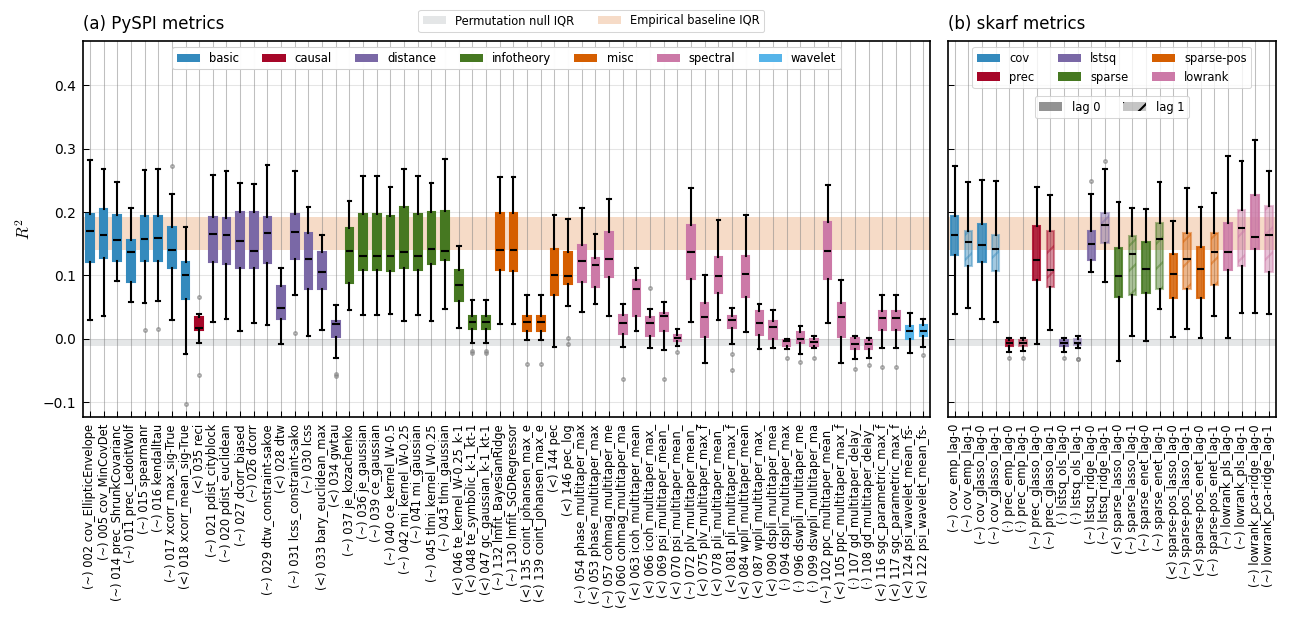

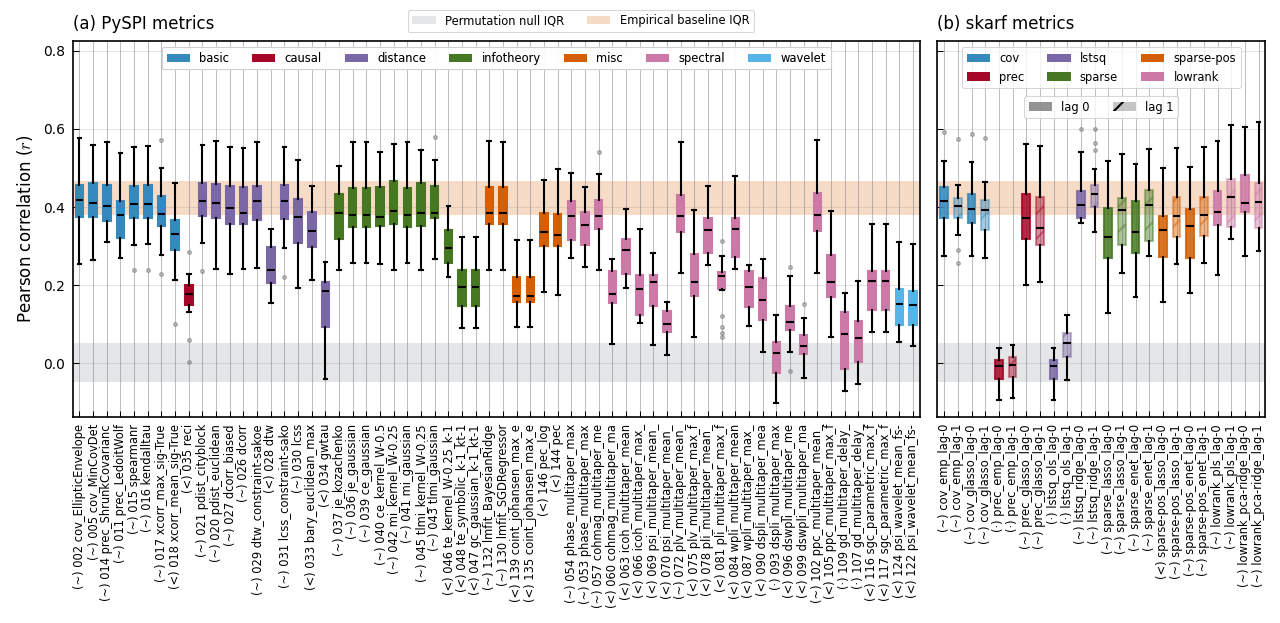

In [6]:
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[metric_key]
    pyspi_panel_df = ctx["pyspi_panel_df"]
    skarf_panel_df = ctx["skarf_panel_df"]
    pyspi_category_colors = ctx["pyspi_category_colors"]
    skarf_label_map = ctx["skarf_label_map"]
    skarf_func_order = ctx["skarf_func_order"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            baseline_q25,
            baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Empirical baseline IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_panel_df["category"].unique()
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    plt.subplots_adjust(wspace=0.03)

    # figure_base = PLOT_DIR / f"figure2_pyspi_skarf_cognition_{suffix}"
    # fig.savefig(f"{figure_base}.png", dpi=300)
    # fig.savefig(f"{figure_base}.pdf")
    # print(f"Saved poster figure for {metric_key} to {figure_base}.png/.pdf")
    plt.show()

**Figure 2.** Predictive accuracy of connectivity representations for the HCP cognition factor, rendered identically for both $R^2$ and Pearson correlation ($r$) metrics. (a) PySPI metrics are grouped by SPI family; only the top-$k$ performers per family are shown, with colors denoting module classes and semi-transparent bands indicating the permutation-null and empirical covariance interquartile ranges. (b) skarf VAR estimators display lag-0 (solid) and lag-1 (hatched) distributions for each function category, sharing the same null/baseline reference bands. Notation: (·) indicates performance not exceeding the permutation-derived null (Bonferroni-corrected), (~) denotes no detectable difference from the baseline, and (<)/(>) flag significantly lower/higher performance relative to empirical covariance. Mann-Whitney U test was used to assess significance (one-sided for null, two-sided for baseline). Error distributions summarize 20 outer splits with identical cross-validation folds across methods.

## 6. Load Sparse Behavioral Prediction Results

In [7]:
sparse_result_dir = PROJECT_ROOT / "results/hcp_1200_sparse_behav_prediction/sparsity-0.80__parc-200__pool-3__n-20__perm-0__seed-2142"
sparsity_csv_path = "/srv/projects/skarf/sparsity_computation/sparsity_by_function_all_thresholds.parquet"

# Load sparse results
sparse_result_paths = sorted(sparse_result_dir.rglob("results.json"))
if not sparse_result_paths:
    raise FileNotFoundError(f"No sparse results found under {sparse_result_dir}")

# Extract method, func, and lag from directory structure
def extract_method_func_lag(path: Path) -> tuple:
    """Extract method, func, and lag from directory path."""
    parts = path.parent.parent.name.split("__")
    method_id = int(parts[0])
    method = parts[1]
    func = parts[2]
    lag = None
    if len(parts) > 3 and parts[3].startswith("lag-"):
        lag = int(parts[3].split("-")[1])
    return method, func, lag

# Build metadata lookup: path -> (method, func, lag)
path_metadata = []
for path in sparse_result_paths:
    method, func, lag = extract_method_func_lag(path)
    df = pd.read_json(path, lines=True)
    df["method"] = method
    df["func"] = func
    df["lag"] = lag
    path_metadata.append(df)

sparse_results = pd.concat(path_metadata, ignore_index=True)

# Load natural sparsity metadata
sparsity_df = pd.read_parquet(sparsity_csv_path)
sparsity_df = sparsity_df.rename(columns={"function": "func"})

# Merge sparse results with natural sparsity metadata
sparse_results = sparse_results.merge(
    sparsity_df[["method", "func", "sparsity_t0.05"]],
    on=["method", "func"],
    how="left"
)

# Separate PySPI and skarf sparse results
sparse_pyspi = sparse_results[sparse_results["method"] == "pyspi"].copy()
sparse_skarf = sparse_results[sparse_results["method"] == "skarf"].copy()

# Exclude degenerate matrices
sparse_pyspi = sparse_pyspi[~sparse_pyspi["func"].apply(lambda s: f"pyspi__{s}" in degenerate_keys)].copy()
sparse_skarf = sparse_skarf[~sparse_skarf["func"].apply(lambda f: f"skarf__{f}" in degenerate_keys)].copy()

# For PySPI, map func to spi and merge with spi_table for category information
sparse_pyspi = sparse_pyspi.rename(columns={"func": "spi"})
sparse_pyspi["spi"] = pd.Categorical(sparse_pyspi["spi"], categories=spi_list, ordered=True)
sparse_pyspi = spi_table.merge(sparse_pyspi, on="spi", how="right")
sparse_pyspi = sparse_pyspi.dropna(subset=["spi"])
sparse_pyspi["category"] = pd.Categorical(
    sparse_pyspi["category"], categories=category_levels, ordered=True
)
sparse_pyspi["identifier"] = pd.Categorical(
    sparse_pyspi["identifier"], categories=identifier_levels, ordered=True
)

# For skarf, add category information
sparse_skarf["func"] = pd.Categorical(
    sparse_skarf["func"], categories=AVAILABLE_SKARF_FUNCS, ordered=True
)
sparse_skarf = sparse_skarf.dropna(subset=["func"])
sparse_skarf["category"] = sparse_skarf["func"].map(func_category_map)
sparse_skarf["lag"] = sparse_skarf["lag"].fillna(0).astype(int)

print(f"Loaded {len(sparse_pyspi)} PySPI sparse results and {len(sparse_skarf)} skarf sparse results")
print(f"PySPI unique methods: {sparse_pyspi['spi'].nunique()}")
print(f"skarf unique functions: {sparse_skarf['func'].nunique()}, lags: {sorted(sparse_skarf['lag'].unique())}")


Loaded 10120760 PySPI sparse results and 3306080 skarf sparse results
PySPI unique methods: 146
skarf unique functions: 12, lags: [0, 1]


/tmp/ipykernel_439651/2371961534.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sparse_skarf["lag"] = sparse_skarf["lag"].fillna(0).astype(int)


## 7. Build Metric-Specific Sparse Contexts

In [8]:
sparse_metric_contexts = {}

# Define colors for reference bands
SPARSE_BASELINE_COLOR = "#7570b3"  # Purple for sparse empirical cov

for metric_key, meta in METRIC_CONFIGS.items():
    # Reuse non-sparse baseline and permutation null
    perm_null_values = metric_contexts[metric_key]["perm_null_values"]
    nonsparse_baseline_reference = metric_contexts[metric_key]["baseline_reference"]
    nonsparse_baseline_score = metric_contexts[metric_key]["baseline_score"]
    
    # Get sparse empirical covariance baseline
    sparse_emp_cov_pyspi = sparse_pyspi[sparse_pyspi["spi"] == "cov_EmpiricalCovariance"]
    sparse_baseline_reference = sparse_emp_cov_pyspi[metric_key].dropna().values
    
    if sparse_baseline_reference.size == 0:
        raise ValueError(f"No sparse empirical covariance baseline for metric {metric_key}")
    
    sparse_baseline_score = float(np.median(sparse_baseline_reference))
    sparse_baseline_q25, sparse_baseline_q75 = np.nanpercentile(sparse_baseline_reference, [25, 75])
    
    # Keep non-sparse baseline stats for comparison
    nonsparse_baseline_q25 = metric_contexts[metric_key]["baseline_q25"]
    nonsparse_baseline_q75 = metric_contexts[metric_key]["baseline_q75"]
    perm_q25 = metric_contexts[metric_key]["perm_q25"]
    perm_q75 = metric_contexts[metric_key]["perm_q75"]
    
    # Process PySPI sparse results
    pyspi_sparse_values = (
        sparse_pyspi.groupby(["category", "identifier", "spi"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    pyspi_sparse_values["values"] = pyspi_sparse_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    pyspi_sparse_values["median"] = pyspi_sparse_values["values"].apply(
        lambda arr: np.median(arr) if arr.size else np.nan
    )
    pyspi_sparse_values = pyspi_sparse_values.sort_values(
        ["category", "identifier", "median"], ascending=[True, True, False]
    )
    
    pyspi_sparse_panel_rows = []
    for (category, identifier), df_cat in pyspi_sparse_values.groupby(["category", "identifier"], sort=False):
        head_df = df_cat.head(TOPK_PER_CATEGORY)
        for _, row in head_df.iterrows():
            values = row["values"]
            if values.size == 0:
                continue
            null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
            baseline_pval = stats.mannwhitneyu(values, sparse_baseline_reference).pvalue
            spi = row["spi"]
            base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
            pyspi_sparse_panel_rows.append(
                {
                    "category": category,
                    "identifier": identifier,
                    "spi": spi,
                    "values": values,
                    "median": np.median(values),
                    "null_pval": null_pval,
                    "baseline_pval": baseline_pval,
                    "base_label": base_label,
                }
            )
    
    pyspi_sparse_panel_df = pd.DataFrame(pyspi_sparse_panel_rows)
    if not pyspi_sparse_panel_df.empty:
        pyspi_sparse_panel_df["color"] = pyspi_sparse_panel_df["category"].map(pyspi_category_colors)
    pyspi_sparse_tests = max(len(pyspi_sparse_panel_df), 1)
    if not pyspi_sparse_panel_df.empty:
        pyspi_sparse_panel_df["plot_label"] = pyspi_sparse_panel_df.apply(
            lambda row: format_label(
                row["base_label"],
                row["values"],
                row["null_pval"],
                row["baseline_pval"],
                pyspi_sparse_tests,
                sparse_baseline_score,
            ),
            axis=1,
        )
    else:
        pyspi_sparse_panel_df["plot_label"] = pd.Series(dtype=str)
    
    # Process skarf sparse results
    skarf_sparse_values = (
        sparse_skarf.groupby(["func", "lag"], observed=True)[metric_key]
        .apply(lambda vals: vals.values)
        .reset_index(name="values")
    )
    skarf_sparse_values["values"] = skarf_sparse_values["values"].apply(lambda arr: arr[~np.isnan(arr)])
    skarf_sparse_values["median"] = skarf_sparse_values["values"].apply(
        lambda arr: np.median(arr) if arr.size else np.nan
    )
    
    skarf_sparse_panel_rows = []
    for _, row in skarf_sparse_values.iterrows():
        values = row["values"]
        if values.size == 0:
            continue
        func = row["func"]
        lag = int(row["lag"])
        category = func_category_map[func]
        color = func_category_colors[category]
        base_label = func_display_names.get(func, func)
        null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
        baseline_pval = stats.mannwhitneyu(values, sparse_baseline_reference).pvalue
        skarf_sparse_panel_rows.append(
            {
                "func": func,
                "lag": lag,
                "category": category,
                "values": values,
                "median": np.median(values),
                "null_pval": null_pval,
                "baseline_pval": baseline_pval,
                "base_label": base_label,
                "color": color,
            }
        )
    
    skarf_sparse_panel_df = pd.DataFrame(skarf_sparse_panel_rows)
    skarf_sparse_tests = max(len(skarf_sparse_panel_df), 1)
    if not skarf_sparse_panel_df.empty:
        skarf_sparse_panel_df["plot_label"] = skarf_sparse_panel_df.apply(
            lambda row: format_label(
                row["base_label"],
                row["values"],
                row["null_pval"],
                row["baseline_pval"],
                skarf_sparse_tests,
                sparse_baseline_score,
            ),
            axis=1,
        )
    else:
        skarf_sparse_panel_df["plot_label"] = pd.Series(dtype=str)
    
    skarf_sparse_label_map = {}
    for _, row in skarf_sparse_panel_df.iterrows():
        func = row["func"]
        lag = int(row["lag"])
        label_with_lag = f"{row['plot_label']}_lag-{lag}".strip()
        skarf_sparse_label_map[(func, lag)] = label_with_lag
    
    skarf_sparse_funcs_present = [
        func for func in AVAILABLE_SKARF_FUNCS if func in skarf_sparse_panel_df["func"].unique()
    ]
    
    sparse_metric_contexts[metric_key] = {
        "metric_key": metric_key,
        "metric_label": meta["label"],
        "suffix": meta["suffix"],
        "perm_null_values": perm_null_values,
        "nonsparse_baseline_reference": nonsparse_baseline_reference,
        "nonsparse_baseline_score": nonsparse_baseline_score,
        "sparse_baseline_reference": sparse_baseline_reference,
        "sparse_baseline_score": sparse_baseline_score,
        "perm_q25": perm_q25,
        "perm_q75": perm_q75,
        "nonsparse_baseline_q25": nonsparse_baseline_q25,
        "nonsparse_baseline_q75": nonsparse_baseline_q75,
        "sparse_baseline_q25": sparse_baseline_q25,
        "sparse_baseline_q75": sparse_baseline_q75,
        "pyspi_sparse_panel_df": pyspi_sparse_panel_df,
        "pyspi_category_colors": pyspi_category_colors,
        "skarf_sparse_panel_df": skarf_sparse_panel_df,
        "skarf_sparse_label_map": skarf_sparse_label_map,
        "skarf_sparse_func_order": skarf_sparse_funcs_present,
    }
    
    print(
        f"Prepared sparse context for {metric_key} "
        f"(sparse baseline {sparse_baseline_score:.3f}, non-sparse baseline {nonsparse_baseline_score:.3f}, "
        f"PySPI entries {len(pyspi_sparse_panel_df)}, skarf entries {len(skarf_sparse_panel_df)})"
    )

/tmp/ipykernel_439651/2550674627.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_sparse_values.groupby(["category", "identifier"], sort=False):


Prepared sparse context for r2_test (sparse baseline 0.149, non-sparse baseline 0.164, PySPI entries 62, skarf entries 24)


/tmp/ipykernel_439651/2550674627.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (category, identifier), df_cat in pyspi_sparse_values.groupby(["category", "identifier"], sort=False):


Prepared sparse context for corr_test (sparse baseline 0.397, non-sparse baseline 0.435, PySPI entries 62, skarf entries 24)


## 9. Plot Figure 3 – Sparse Behavioral Prediction (0.8 Sparsity)

Saved sparse poster figure for r2_test to /home/aerkent/skarf-experiments/results/poster_figures/figure3_sparse_pyspi_skarf_cognition_r2.png/.pdf


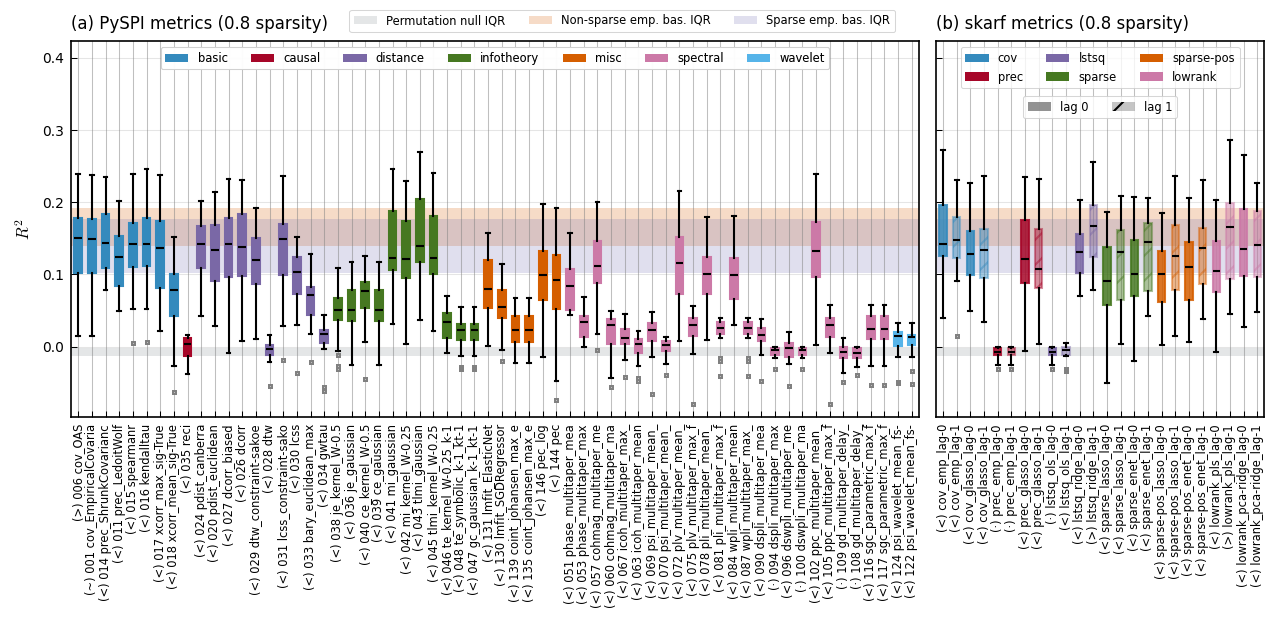

Saved sparse poster figure for corr_test to /home/aerkent/skarf-experiments/results/poster_figures/figure3_sparse_pyspi_skarf_cognition_corr.png/.pdf


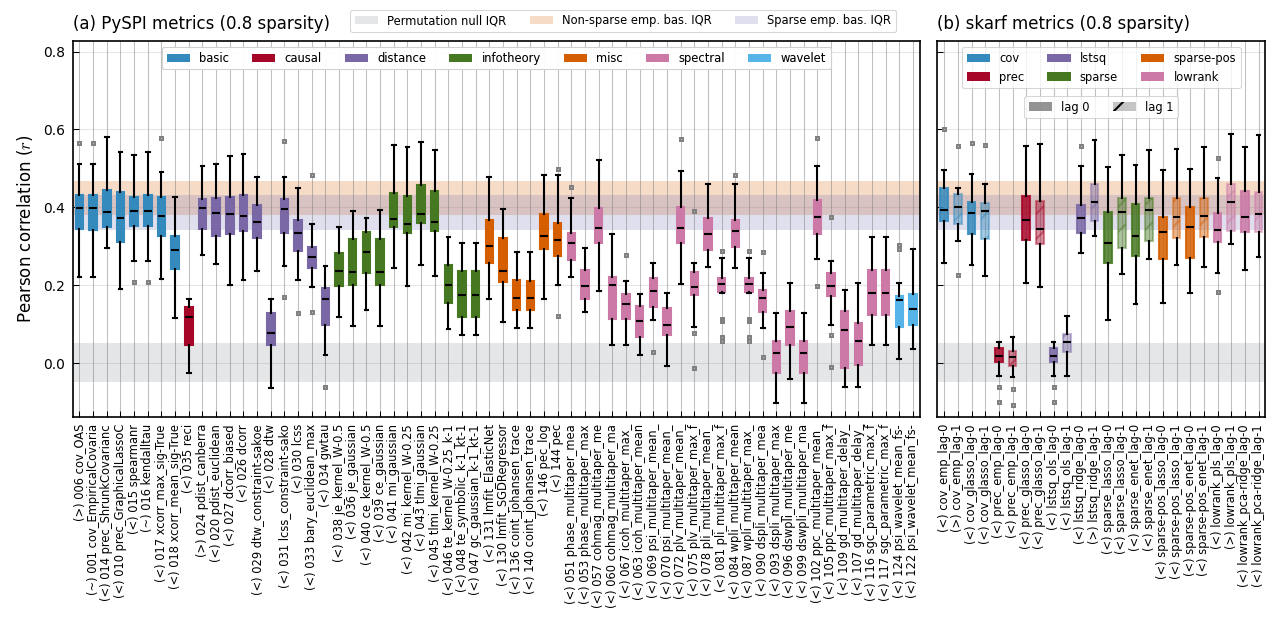

In [9]:
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = sparse_metric_contexts[metric_key]
    pyspi_sparse_panel_df = ctx["pyspi_sparse_panel_df"]
    skarf_sparse_panel_df = ctx["skarf_sparse_panel_df"]
    pyspi_category_colors = ctx["pyspi_category_colors"]
    skarf_sparse_label_map = ctx["skarf_sparse_label_map"]
    skarf_sparse_func_order = ctx["skarf_sparse_func_order"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    nonsparse_baseline_q25 = ctx["nonsparse_baseline_q25"]
    nonsparse_baseline_q75 = ctx["nonsparse_baseline_q75"]
    sparse_baseline_q25 = ctx["sparse_baseline_q25"]
    sparse_baseline_q75 = ctx["sparse_baseline_q75"]
    
    pyspi_count = max(len(pyspi_sparse_panel_df), 1)
    skarf_count = max(len(skarf_sparse_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )
    
    # Panel (a): PySPI sparse
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            nonsparse_baseline_q25,
            nonsparse_baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Non-sparse emp. bas. IQR",
        ),
        add_iqr_band(
            ax,
            sparse_baseline_q25,
            sparse_baseline_q75,
            SPARSE_BASELINE_COLOR,
            BASELINE_BAND_ALPHA,
            label="Sparse emp. bas. IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_sparse_panel_df))
    if len(pyspi_sparse_panel_df):
        pyspi_data = pyspi_sparse_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_sparse_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_sparse_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics (0.8 sparsity)", loc="left", fontsize="medium")
    if len(pyspi_sparse_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_sparse_panel_df["category"].unique()
    ] if len(pyspi_sparse_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.65, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)
    
    # Panel (b): skarf sparse
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, nonsparse_baseline_q25, nonsparse_baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    add_iqr_band(ax, sparse_baseline_q25, sparse_baseline_q75, SPARSE_BASELINE_COLOR, BASELINE_BAND_ALPHA)
    if skarf_sparse_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_sparse_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_sparse_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_sparse_panel_df.loc[skarf_sparse_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_sparse_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_sparse_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics (0.8 sparsity)", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())
    
    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)
    
    for axis in axes:
        axis.grid(alpha=0.2, axis="y")
    
    plt.subplots_adjust(wspace=0.03)
    
    figure_base = PLOT_DIR / f"figure3_sparse_pyspi_skarf_cognition_{suffix}"
    fig.savefig(f"{figure_base}.png", dpi=300)
    fig.savefig(f"{figure_base}.pdf")
    print(f"Saved sparse poster figure for {metric_key} to {figure_base}.png/.pdf")
    plt.show()

**Figure 3.** Predictive accuracy of connectivity representations for the HCP cognition factor under uniform 0.8 imposed sparsity (retaining only top 20% of connections by absolute value), rendered identically for both $R^2$ and Pearson correlation ($r$) metrics. (a) PySPI metrics are grouped by SPI family with top-$k$ performers per family shown, colored by module classes. Three reference bands overlay the distributions: permutation-null IQR (gray), non-sparse empirical covariance IQR (orange), and sparse empirical covariance IQR (purple). (b) skarf VAR estimators display lag-0 (solid) and lag-1 (hatched) distributions for each function category with the same reference bands. Notation follows Figure 2: (·) indicates performance not exceeding the permutation-derived null (Bonferroni-corrected), (~) denotes no detectable difference from the sparse baseline, and (<)/(>) flag significantly lower/higher performance relative to sparse empirical covariance. Mann-Whitney U test was used to assess significance (one-sided for null, two-sided for baseline). Error distributions summarize 20 outer splits with identical cross-validation folds across methods. This figure enables direct comparison of method performance under equal sparsity constraints, separating the effect of sparsity from method choice.

# 10. Plot sorted Figure 2 and 3 - descending order of median performance

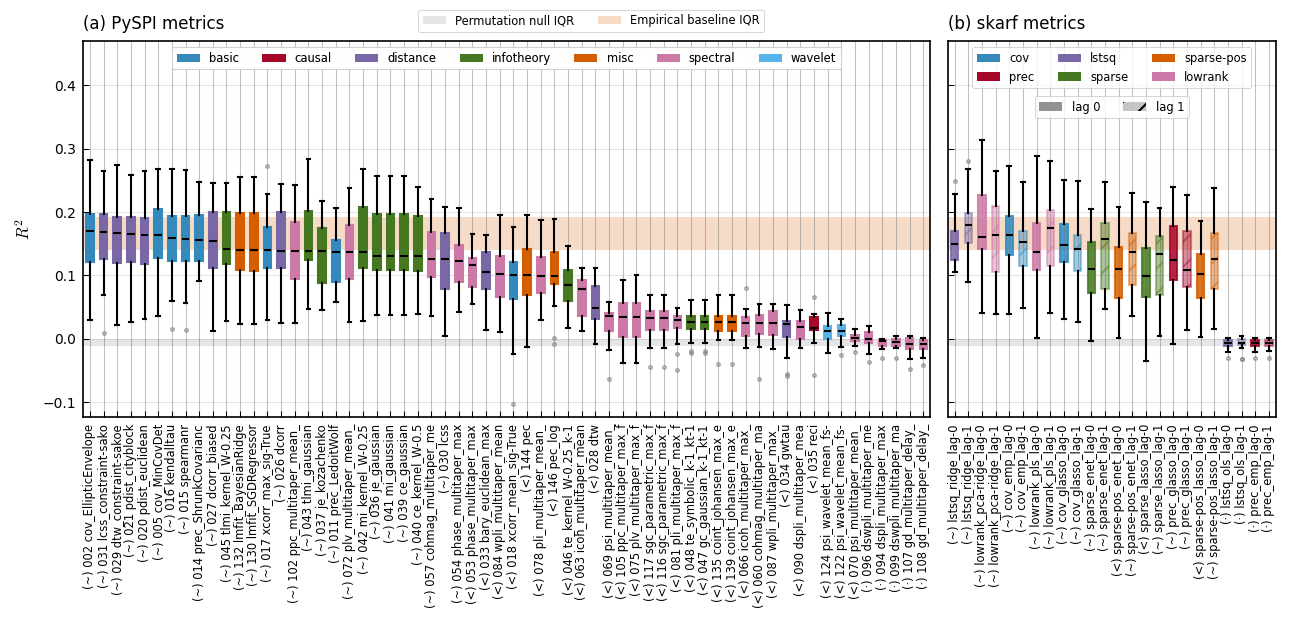

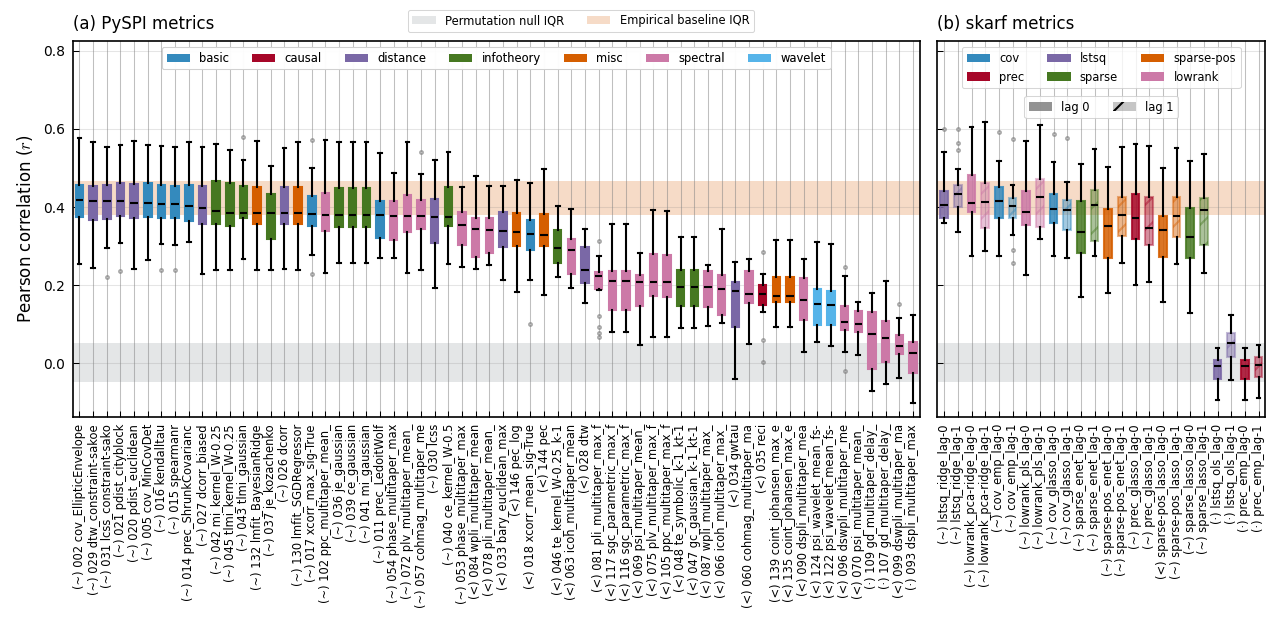

In [10]:
# Figure 2 (sorted) – same as above but boxplots sorted descending by median within each subplot
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[metric_key]
    pyspi_panel_df = ctx["pyspi_panel_df"].sort_values("median", ascending=False).reset_index(drop=True)
    skarf_panel_df = ctx["skarf_panel_df"]
    pyspi_category_colors = ctx["pyspi_category_colors"]
    skarf_label_map = ctx["skarf_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    # Sort skarf func order by per-function median (mean across lags) descending
    func_medians = skarf_panel_df.groupby("func", observed=True)["median"].mean()
    skarf_func_order = sorted(
        ctx["skarf_func_order"],
        key=lambda f: func_medians.get(f, float("-inf")),
        reverse=True,
    )

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            baseline_q25,
            baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Empirical baseline IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_category_colors
        if cat in pyspi_panel_df["category"].values
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    plt.subplots_adjust(wspace=0.03)
    plt.show()

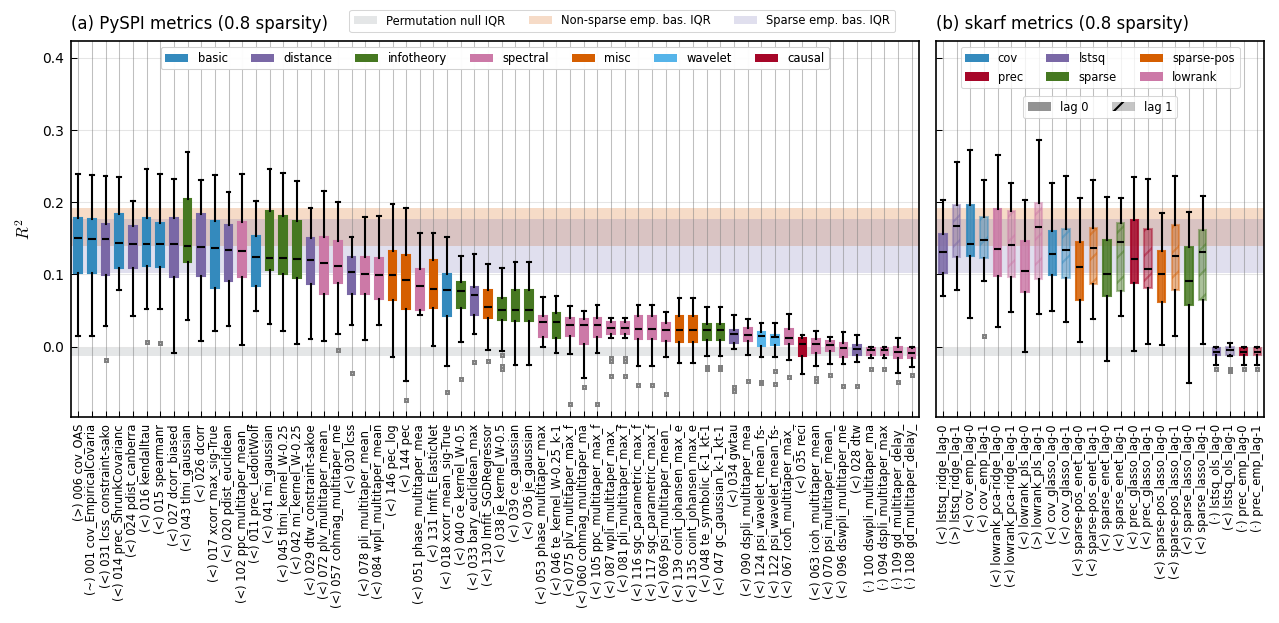

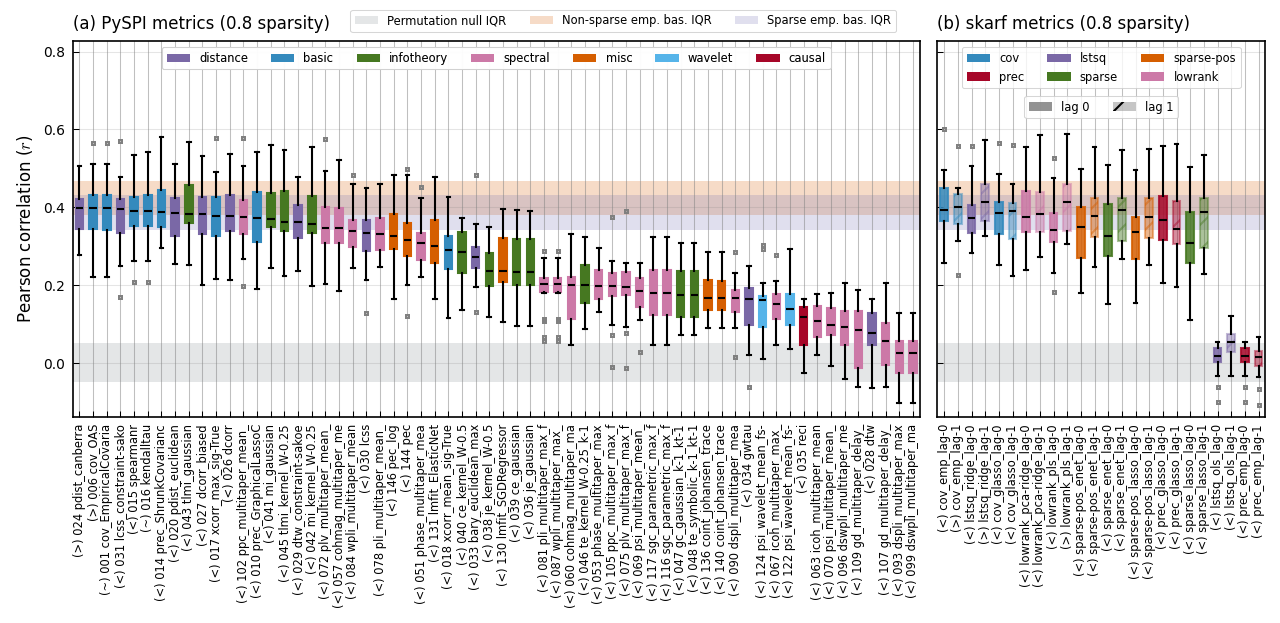

In [11]:
# Figure 3 (sorted) – same as above but boxplots sorted descending by median within each subplot
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = sparse_metric_contexts[metric_key]
    pyspi_sparse_panel_df = ctx["pyspi_sparse_panel_df"].sort_values("median", ascending=False).reset_index(drop=True)
    skarf_sparse_panel_df = ctx["skarf_sparse_panel_df"]
    pyspi_category_colors = ctx["pyspi_category_colors"]
    skarf_sparse_label_map = ctx["skarf_sparse_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    nonsparse_baseline_q25 = ctx["nonsparse_baseline_q25"]
    nonsparse_baseline_q75 = ctx["nonsparse_baseline_q75"]
    sparse_baseline_q25 = ctx["sparse_baseline_q25"]
    sparse_baseline_q75 = ctx["sparse_baseline_q75"]

    # Sort skarf func order by per-function median (mean across lags) descending
    func_medians = skarf_sparse_panel_df.groupby("func", observed=True)["median"].mean()
    skarf_sparse_func_order = sorted(
        ctx["skarf_sparse_func_order"],
        key=lambda f: func_medians.get(f, float("-inf")),
        reverse=True,
    )

    pyspi_count = max(len(pyspi_sparse_panel_df), 1)
    skarf_count = max(len(skarf_sparse_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI sparse
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(
            ax,
            perm_q25,
            perm_q75,
            NULL_BAND_COLOR,
            NULL_BAND_ALPHA,
            label="Permutation null IQR",
        ),
        add_iqr_band(
            ax,
            nonsparse_baseline_q25,
            nonsparse_baseline_q75,
            BASELINE_BAND_COLOR,
            BASELINE_BAND_ALPHA,
            label="Non-sparse emp. bas. IQR",
        ),
        add_iqr_band(
            ax,
            sparse_baseline_q25,
            sparse_baseline_q75,
            SPARSE_BASELINE_COLOR,
            BASELINE_BAND_ALPHA,
            label="Sparse emp. bas. IQR",
        ),
    ]
    pyspi_positions = np.arange(len(pyspi_sparse_panel_df))
    if len(pyspi_sparse_panel_df):
        pyspi_data = pyspi_sparse_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_sparse_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_sparse_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics (0.8 sparsity)", loc="left", fontsize="medium")
    if len(pyspi_sparse_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_sparse_panel_df["category"].unique()
    ] if len(pyspi_sparse_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.65, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf sparse
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, nonsparse_baseline_q25, nonsparse_baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    add_iqr_band(ax, sparse_baseline_q25, sparse_baseline_q75, SPARSE_BASELINE_COLOR, BASELINE_BAND_ALPHA)
    if skarf_sparse_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_sparse_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_sparse_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_sparse_panel_df.loc[skarf_sparse_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_sparse_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_sparse_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics (0.8 sparsity)", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=f"{category}", edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    plt.subplots_adjust(wspace=0.03)
    plt.show()

# 11. Plot total-rank-ordered Figure 2 and Figure 3

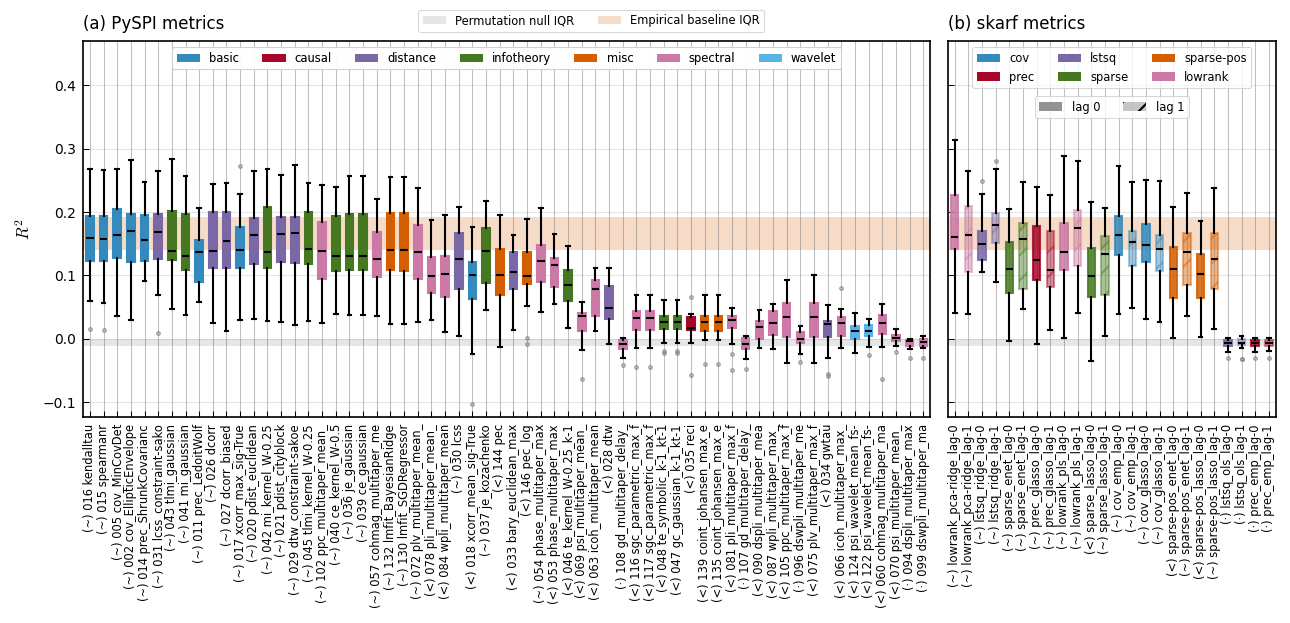

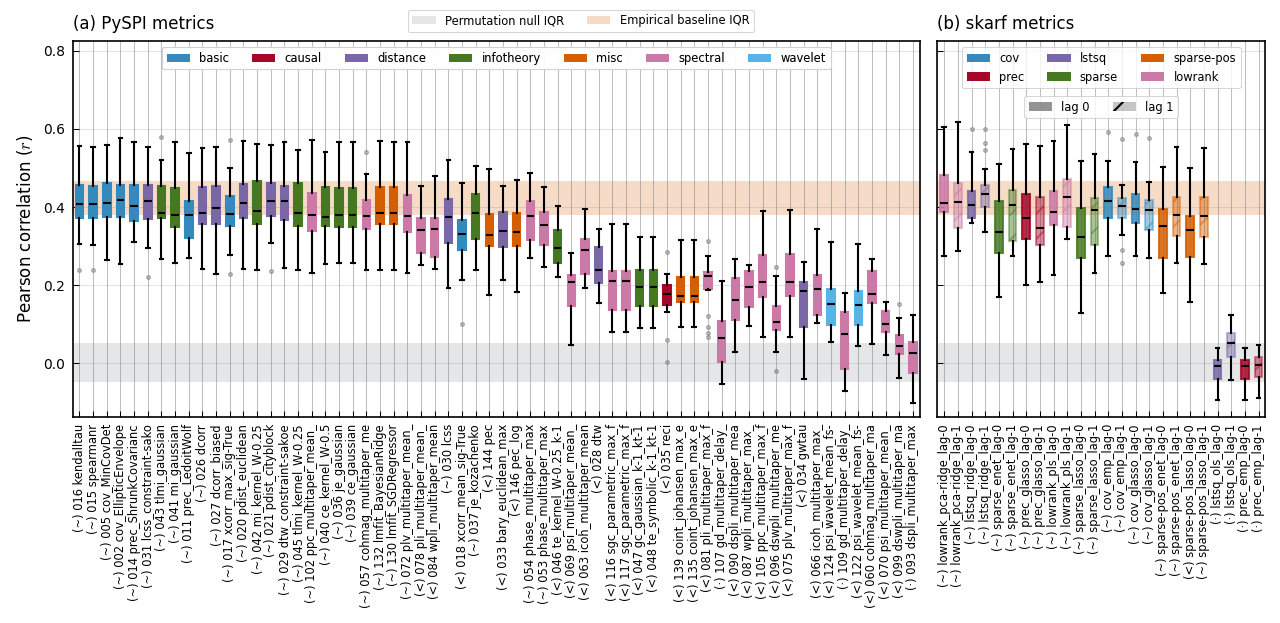

In [12]:
# Figure 2 (rank-ordered) – boxplots ordered by maxnorm_rank_order from combined benchmark scores
_ranked = pd.read_csv(
    PROJECT_ROOT / "results/hcp_1200_benchmark_scores_combined_analysis/combined_benchmark_scores_ranked.csv"
)
_pyspi_rank = _ranked.query("method == 'pyspi' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()
_skarf_rank = _ranked.query("method == 'skarf' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()

for metric_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[metric_key]
    skarf_panel_df = ctx["skarf_panel_df"]
    skarf_label_map = ctx["skarf_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    baseline_q25 = ctx["baseline_q25"]
    baseline_q75 = ctx["baseline_q75"]

    # Sort PySPI by maxnorm_rank_order ascending (lower rank = better = leftmost)
    pyspi_panel_df = ctx["pyspi_panel_df"].copy()
    pyspi_panel_df["_rank"] = pyspi_panel_df["spi"].map(_pyspi_rank)
    pyspi_panel_df = pyspi_panel_df.sort_values("_rank").drop(columns=["_rank"]).reset_index(drop=True)

    # Sort skarf func order by lag-0 maxnorm_rank_order ascending
    skarf_func_order = sorted(
        ctx["skarf_func_order"],
        key=lambda f: _skarf_rank.get(f, float("inf")),
    )

    pyspi_count = max(len(pyspi_panel_df), 1)
    skarf_count = max(len(skarf_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA, label="Permutation null IQR"),
        add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA, label="Empirical baseline IQR"),
    ]
    pyspi_positions = np.arange(len(pyspi_panel_df))
    if len(pyspi_panel_df):
        pyspi_data = pyspi_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title("(a) PySPI metrics", loc="left", fontsize="medium")
    if len(pyspi_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_category_colors
        if cat in pyspi_panel_df["category"].values
    ] if len(pyspi_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, baseline_q25, baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    if skarf_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title("(b) skarf metrics", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=category, edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    plt.subplots_adjust(wspace=0.03)
    plt.show()


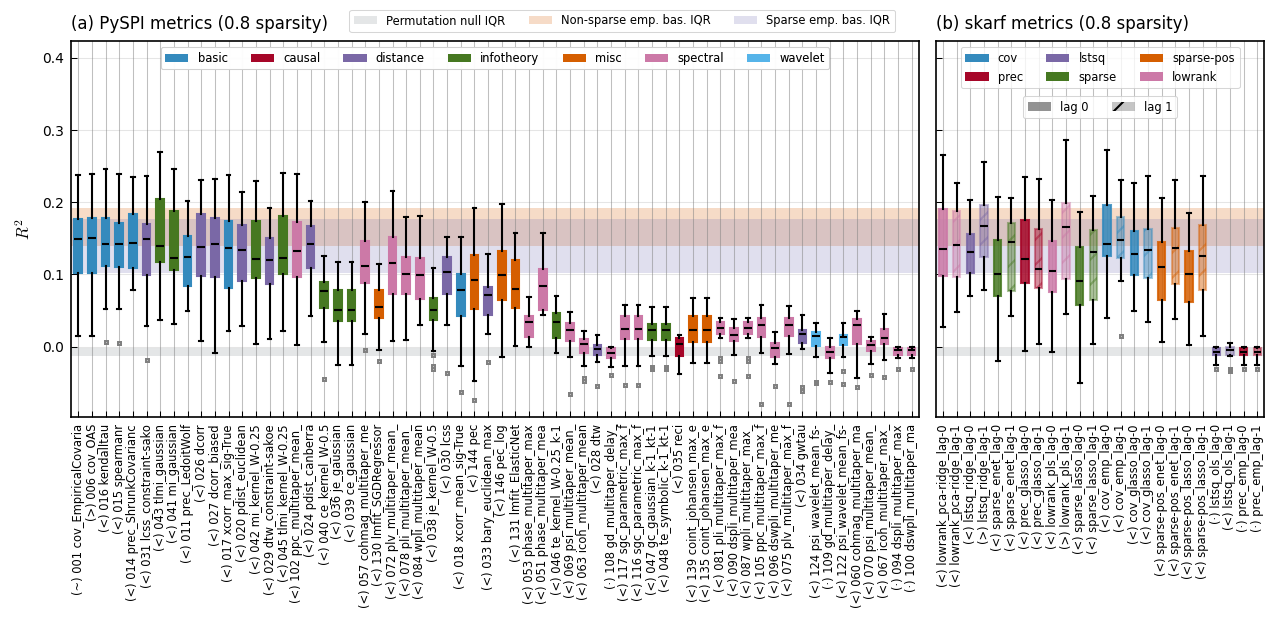

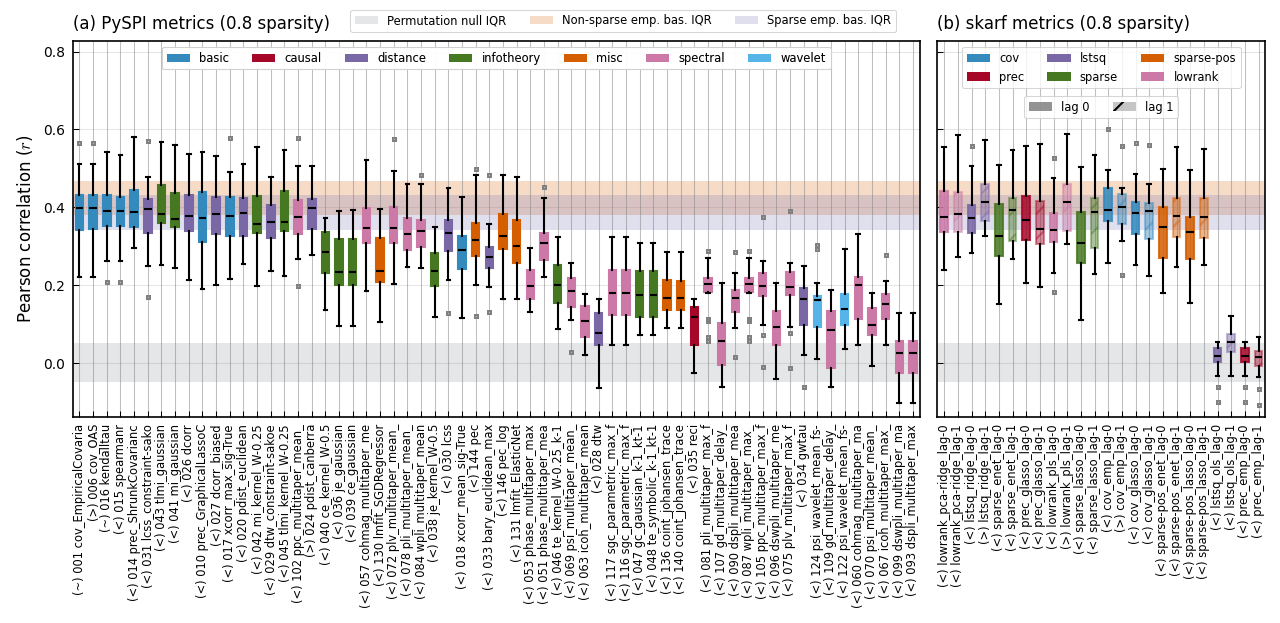

In [13]:
# Figure 3 (rank-ordered) – sparse boxplots ordered by maxnorm_rank_order from combined benchmark scores
# Reuses _pyspi_rank and _skarf_rank built in the Figure 2 rank-ordered cell above

for metric_key, meta in METRIC_CONFIGS.items():
    ctx = sparse_metric_contexts[metric_key]
    skarf_sparse_panel_df = ctx["skarf_sparse_panel_df"]
    skarf_sparse_label_map = ctx["skarf_sparse_label_map"]
    metric_label = ctx["metric_label"]
    suffix = ctx["suffix"]
    perm_q25 = ctx["perm_q25"]
    perm_q75 = ctx["perm_q75"]
    nonsparse_baseline_q25 = ctx["nonsparse_baseline_q25"]
    nonsparse_baseline_q75 = ctx["nonsparse_baseline_q75"]
    sparse_baseline_q25 = ctx["sparse_baseline_q25"]
    sparse_baseline_q75 = ctx["sparse_baseline_q75"]

    # Sort PySPI sparse by maxnorm_rank_order ascending
    pyspi_sparse_panel_df = ctx["pyspi_sparse_panel_df"].copy()
    pyspi_sparse_panel_df["_rank"] = pyspi_sparse_panel_df["spi"].map(_pyspi_rank)
    pyspi_sparse_panel_df = pyspi_sparse_panel_df.sort_values("_rank").drop(columns=["_rank"]).reset_index(drop=True)

    # Sort skarf sparse func order by lag-0 maxnorm_rank_order ascending
    skarf_sparse_func_order = sorted(
        ctx["skarf_sparse_func_order"],
        key=lambda f: _skarf_rank.get(f, float("inf")),
    )

    pyspi_count = max(len(pyspi_sparse_panel_df), 1)
    skarf_count = max(len(skarf_sparse_func_order), 1)
    width_ratios = [pyspi_count, skarf_count * len(LAG_ORDER)]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": width_ratios},
        sharey=True,
    )

    # Panel (a): PySPI sparse
    ax = axes[0]
    pyspi_reference_handles = [
        add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA, label="Permutation null IQR"),
        add_iqr_band(ax, nonsparse_baseline_q25, nonsparse_baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA, label="Non-sparse emp. bas. IQR"),
        add_iqr_band(ax, sparse_baseline_q25, sparse_baseline_q75, SPARSE_BASELINE_COLOR, BASELINE_BAND_ALPHA, label="Sparse emp. bas. IQR"),
    ]
    pyspi_positions = np.arange(len(pyspi_sparse_panel_df))
    if len(pyspi_sparse_panel_df):
        pyspi_data = pyspi_sparse_panel_df["values"].tolist()
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_sparse_panel_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_sparse_panel_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title("(a) PySPI metrics (0.8 sparsity)", loc="left", fontsize="medium")
    if len(pyspi_sparse_panel_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)
    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_category_colors
        if cat in pyspi_sparse_panel_df["category"].values
    ] if len(pyspi_sparse_panel_df) else []
    ref_legend = ax.legend(
        handles=pyspi_reference_handles,
        loc="upper center",
        bbox_to_anchor=(0.65, 1.1),
        ncol=len(pyspi_reference_handles),
        fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles,
            loc="upper center",
            ncol=max(len(pyspi_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf sparse
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    add_iqr_band(ax, nonsparse_baseline_q25, nonsparse_baseline_q75, BASELINE_BAND_COLOR, BASELINE_BAND_ALPHA)
    add_iqr_band(ax, sparse_baseline_q25, sparse_baseline_q75, SPARSE_BASELINE_COLOR, BASELINE_BAND_ALPHA)
    if skarf_sparse_func_order:
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []
        for func_idx, func in enumerate(skarf_sparse_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)
                label = skarf_sparse_label_map.get((func, lag), f"{func} lag{lag}")
                xtick_labels.append(label)
        for lag_idx, lag in enumerate(LAG_ORDER):
            lag_rows = skarf_sparse_panel_df.loc[skarf_sparse_panel_df["lag"] == lag].set_index("func")
            lag_pos = []
            lag_data = []
            for func in skarf_sparse_func_order:
                lag_pos.append(combo_positions[(func, lag)])
                if func in lag_rows.index:
                    lag_data.append(lag_rows.loc[func, "values"])
                else:
                    lag_data.append(np.array([np.nan]))
            box = ax.boxplot(
                lag_data,
                positions=lag_pos,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
                flierprops=OUTLIER_PROPS,
            )
            for func, patch in zip(skarf_sparse_func_order, box["boxes"]):
                color = func_category_colors[func_category_map[func]]
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(lag_styles[lag]["alpha"])
                patch.set_hatch(lag_styles[lag]["hatch"])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title("(b) skarf metrics (0.8 sparsity)", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    category_handles = [
        mpatches.Patch(facecolor=color, label=category, edgecolor="none")
        for category, color in func_category_colors.items()
    ]
    lag_handles = [
        mpatches.Patch(facecolor="gray", alpha=lag_styles[lag]["alpha"], hatch=lag_styles[lag]["hatch"], label=f"lag {lag}")
        for lag in LAG_ORDER
    ]
    cat_legend = ax.legend(
        handles=category_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(category_handles) // 2, 1),
        fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    plt.subplots_adjust(wspace=0.03)
    plt.show()


# 12. Plot total-rank-ordered Figure 2 and 3, including top 15 estimators on the table

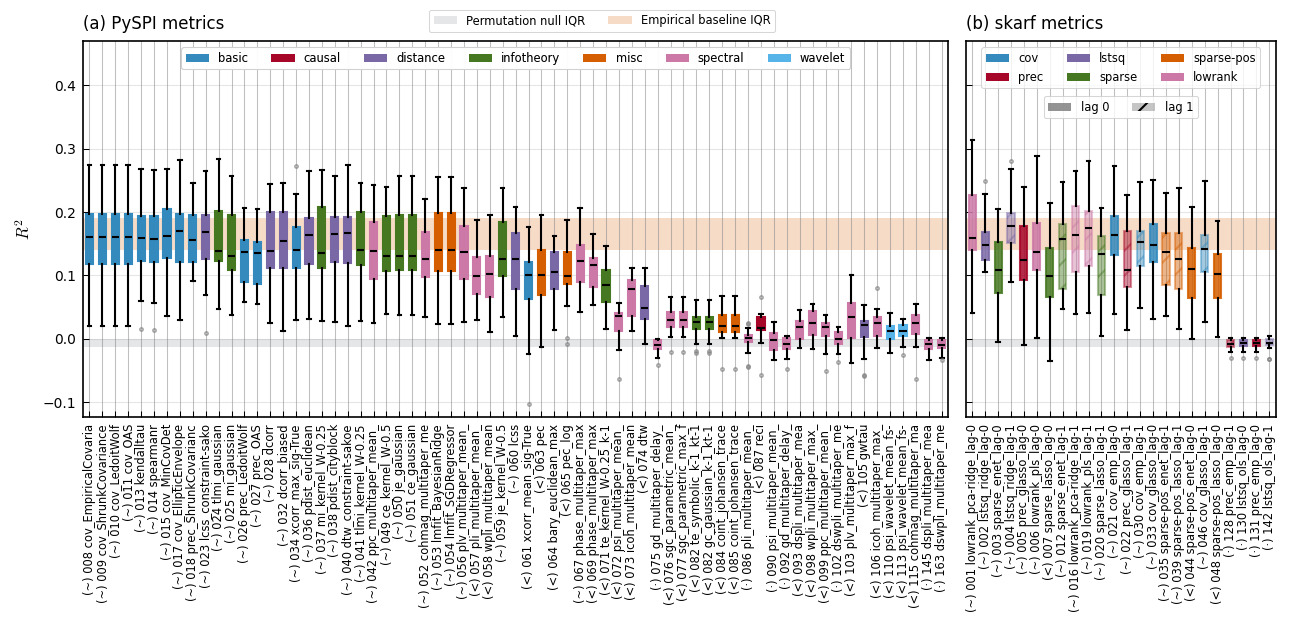

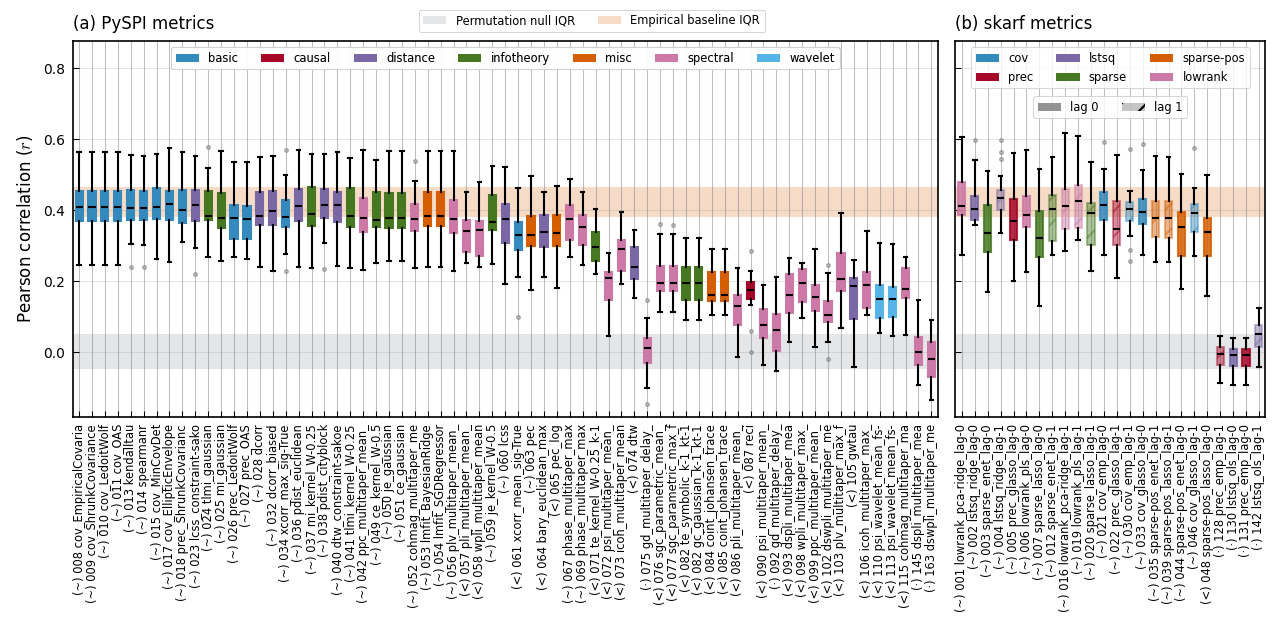

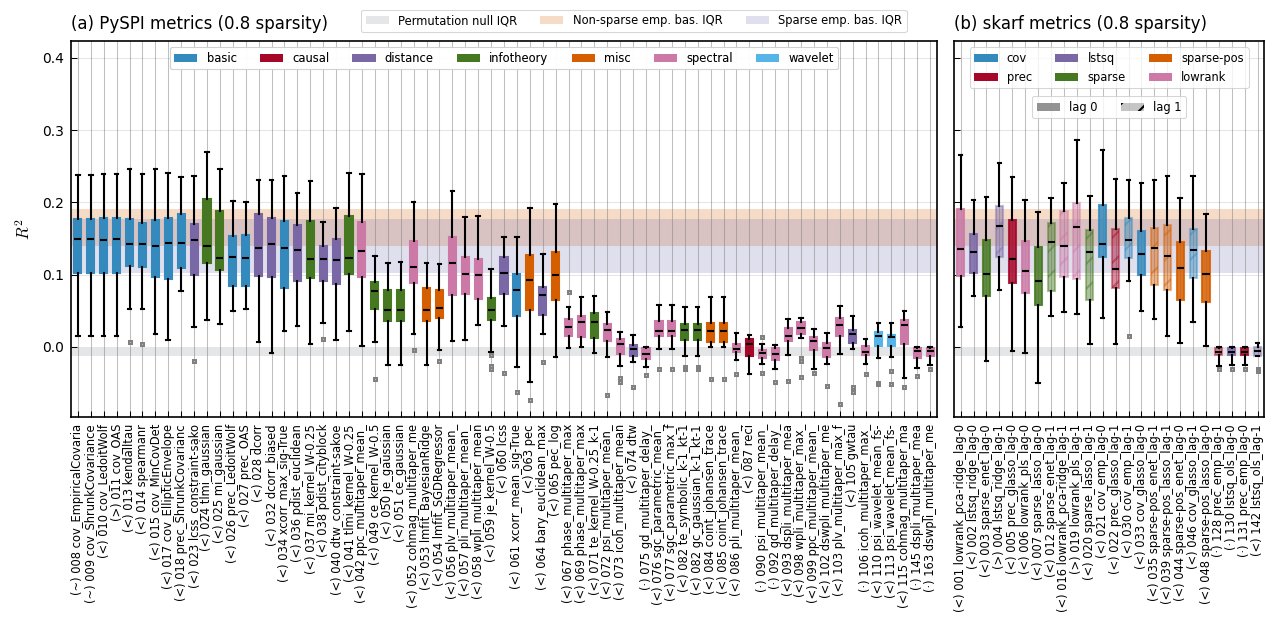

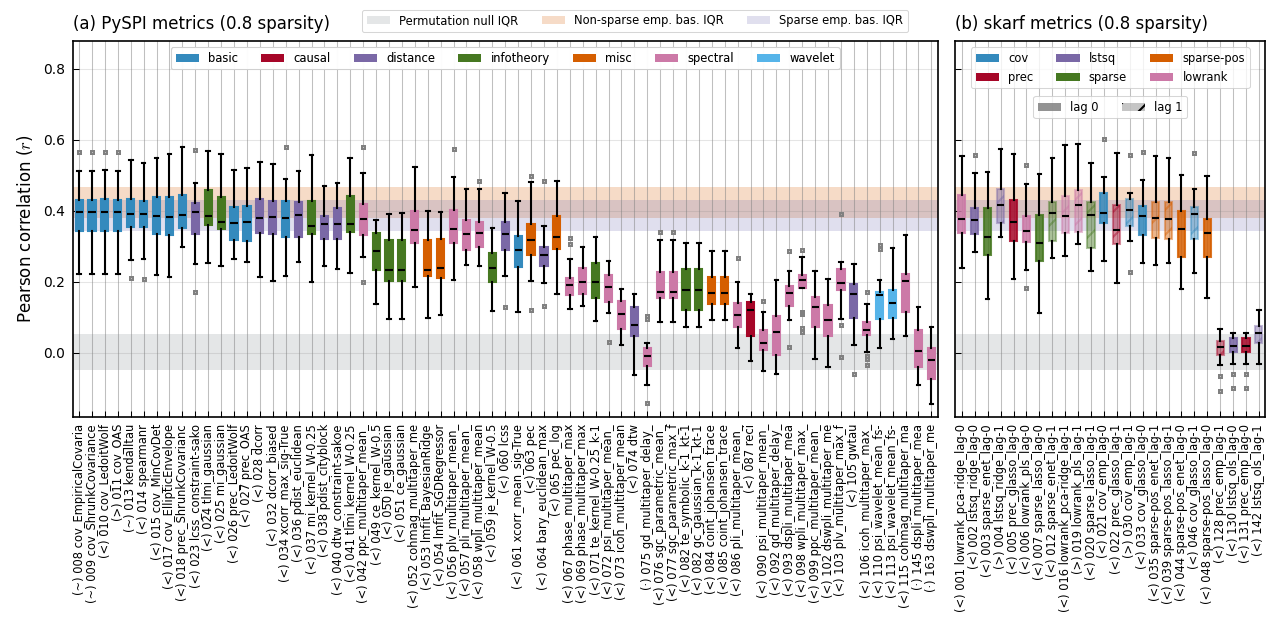

In [18]:
# Figures 2 & 3 – rank-ordered, top-15 global + min-2-per-category PySPI selection
# Selection logic:
#   1. Include all PySPI in the global top-15 by maxnorm_rank_order (lower = better)
#   2. For each (category, identifier) group with < 2 entries from step 1,
#      fill up to 2 with the best-ranked remaining entries from that group
#   3. Sort the final selection by rank ascending; skarf ordered by lag-0 rank
# x-tick labels: significance sign + 3-digit total rank + name (both PySPI and skarf)
# skarf: each (func, lag) gets its own rank number

TOP_K_GLOBAL = 15
TOPK_CATFILL = 2  # minimum per (category, identifier) group

_ranked_table = pd.read_csv(
    PROJECT_ROOT / "results/hcp_1200_benchmark_scores_combined_analysis/combined_benchmark_scores_ranked.csv"
)
# PySPI: single rank per func (lag always 0)
_pr = _ranked_table.query("method == 'pyspi' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()
# skarf: keyed by (func, lag) so each combination gets its own rank
_sr = {
    (row["func"], int(row["lag"])): int(row["maxnorm_rank_order"])
    for _, row in _ranked_table.query("method == 'skarf'").iterrows()
}
# lag-0 only dict used for ordering func groups (sort key)
_sr_lag0 = _ranked_table.query("method == 'skarf' and lag == 0").set_index("func")["maxnorm_rank_order"].to_dict()


def _select_pyspi_panel(base_df, metric_key, rank_map, perm_null_values, baseline_reference,
                        baseline_score, category_colors):
    """Build a PySPI panel df using top-K global + min-2-per-category fallback, sorted by rank.
    x-tick labels use 3-digit total rank (from rank_map)."""
    all_vals = (
        base_df.groupby(["category", "identifier", "spi"], observed=True)[metric_key]
        .apply(lambda v: v.values)
        .reset_index(name="values")
    )
    all_vals["values"] = all_vals["values"].apply(lambda a: a[~np.isnan(a)])
    all_vals["median"] = all_vals["values"].apply(lambda a: np.median(a) if a.size else np.nan)
    all_vals["_rank"] = all_vals["spi"].map(rank_map)
    ranked_only = all_vals.dropna(subset=["_rank"])

    # Step 1: global top-15
    selected = set(ranked_only.nsmallest(TOP_K_GLOBAL, "_rank")["spi"])

    # Step 2: fill each (category, identifier) group up to TOPK_CATFILL
    for (cat, ident), grp in ranked_only.groupby(["category", "identifier"], sort=False, observed=False):
        already = sum(1 for s in grp["spi"] if s in selected)
        if already < TOPK_CATFILL:
            fill = (
                grp[~grp["spi"].isin(selected)]
                .nsmallest(TOPK_CATFILL - already, "_rank")
            )
            selected.update(fill["spi"])

    panel = all_vals[all_vals["spi"].isin(selected)].sort_values("_rank").reset_index(drop=True)
    n_tests = max(len(panel), 1)

    rows = []
    for _, row in panel.iterrows():
        values = row["values"]
        if values.size == 0:
            continue
        null_pval = stats.mannwhitneyu(values, perm_null_values, alternative="greater").pvalue
        baseline_pval = stats.mannwhitneyu(values, baseline_reference).pvalue
        spi = row["spi"]
        rank_num = int(rank_map.get(spi, 0))
        base_label = f"{rank_num:03d} {spi[:20]}"
        rows.append({
            "category": row["category"],
            "identifier": row["identifier"],
            "spi": spi,
            "values": values,
            "median": row["median"],
            "color": category_colors.get(row["category"], "gray"),
            "plot_label": format_label(base_label, values, null_pval, baseline_pval, n_tests, baseline_score),
        })
    return pd.DataFrame(rows)


def _plot_rank_panel(pyspi_df, skarf_panel_df, skarf_label_map, skarf_func_order,
                     metric_label, perm_q25, perm_q75, baseline_bands,
                     skarf_rank_map, title_suffix=""):
    """Render a dual-panel boxplot figure and call plt.show().
    skarf_rank_map: dict (func, lag) -> total rank (int), prepended as 3-digit rank to xtick labels."""
    pyspi_count = max(len(pyspi_df), 1)
    skarf_count = max(len(skarf_func_order) * len(LAG_ORDER), 1)
    fig, axes = plt.subplots(
        1, 2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": [pyspi_count, skarf_count]},
        sharey=True,
    )

    # Panel (a): PySPI
    ax = axes[0]
    ref_handles = [add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA, label="Permutation null IQR")]
    for (q25, q75, color, label) in baseline_bands:
        ref_handles.append(add_iqr_band(ax, q25, q75, color, BASELINE_BAND_ALPHA, label=label))

    pyspi_positions = np.arange(len(pyspi_df))
    if len(pyspi_df):
        pyspi_box = ax.boxplot(
            pyspi_df["values"].tolist(),
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color in zip(pyspi_box["boxes"], pyspi_df["color"]):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(pyspi_df["plot_label"], rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_ylabel(metric_label, fontsize="medium")
    ax.set_title(f"(a) PySPI metrics{title_suffix}", loc="left", fontsize="medium")
    if len(pyspi_df):
        ax.set_ylim(ax.get_ylim()[0], (ax.get_ylim()[1] - ax.get_ylim()[0]) * 1.1)

    pyspi_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[cat], edgecolor="none", label=cat)
        for cat in pyspi_category_colors
        if cat in pyspi_df["category"].values
    ] if len(pyspi_df) else []
    ref_legend = ax.legend(
        handles=ref_handles, loc="upper center",
        bbox_to_anchor=(0.65 if len(baseline_bands) > 1 else 0.6, 1.1),
        ncol=len(ref_handles), fontsize="x-small",
    )
    if pyspi_handles:
        cat_legend = ax.legend(
            handles=pyspi_handles, loc="upper center",
            ncol=max(len(pyspi_handles), 1), fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    ax.add_artist(ref_legend)

    # Panel (b): skarf
    ax = axes[1]
    add_iqr_band(ax, perm_q25, perm_q75, NULL_BAND_COLOR, NULL_BAND_ALPHA)
    for (q25, q75, color, _) in baseline_bands:
        add_iqr_band(ax, q25, q75, color, BASELINE_BAND_ALPHA)

    if skarf_func_order:
        # Sort all (func, lag) combos globally by their individual rank
        all_combos = [(func, lag) for func in skarf_func_order for lag in LAG_ORDER]
        all_combos.sort(key=lambda fl: skarf_rank_map.get(fl, float("inf")))

        xtick_positions, xtick_labels = [], []
        combo_data, combo_colors, combo_alphas, combo_hatches = [], [], [], []
        for pos, (func, lag) in enumerate(all_combos):
            xtick_positions.append(pos)
            raw = skarf_label_map.get((func, lag), f"{func} lag{lag}")
            rank_num = int(skarf_rank_map.get((func, lag), 0))
            # Insert 3-digit rank after the leading significance prefix "(x) "
            if raw and raw[0] == "(":
                label = f"{raw[:4]}{rank_num:03d} {raw[4:]}"
            else:
                label = f"{rank_num:03d} {raw}"
            xtick_labels.append(label)
            lag_rows = skarf_panel_df.loc[skarf_panel_df["lag"] == lag].set_index("func")
            combo_data.append(lag_rows.loc[func, "values"] if func in lag_rows.index else np.array([np.nan]))
            combo_colors.append(func_category_colors[func_category_map[func]])
            combo_alphas.append(lag_styles[lag]["alpha"])
            combo_hatches.append(lag_styles[lag]["hatch"])

        box = ax.boxplot(
            combo_data,
            positions=xtick_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
            flierprops=OUTLIER_PROPS,
        )
        for patch, color, alpha, hatch in zip(box["boxes"], combo_colors, combo_alphas, combo_hatches):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(alpha)
            patch.set_hatch(hatch)
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])
    ax.set_title(f"(b) skarf metrics{title_suffix}", loc="left", fontsize="medium")
    ax.set_ylim(axes[0].get_ylim())

    cat_legend = ax.legend(
        handles=[mpatches.Patch(facecolor=c, label=cat, edgecolor="none") for cat, c in func_category_colors.items()],
        loc="upper center", bbox_to_anchor=(0.5, 1),
        ncol=max(len(func_category_colors) // 2, 1), fontsize="x-small",
    )
    lag_legend = ax.legend(
        handles=[mpatches.Patch(facecolor="gray", alpha=lag_styles[l]["alpha"], hatch=lag_styles[l]["hatch"], label=f"lag {l}") for l in LAG_ORDER],
        loc="upper center", bbox_to_anchor=(0.5, 0.87),
        ncol=len(LAG_ORDER), fontsize="x-small",
    )
    ax.add_artist(cat_legend)
    for axis in axes:
        axis.grid(alpha=0.2, axis="y")
    plt.subplots_adjust(wspace=0.03)
    plt.show()


# ── Figure 2 (non-sparse) ──────────────────────────────────────────────────────
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = metric_contexts[metric_key]
    perm_null = ctx["perm_null_values"]
    baseline_ref = ctx["baseline_reference"]
    baseline_score = ctx["baseline_score"]

    pyspi_panel_df = _select_pyspi_panel(
        pyspi_cognition_base, metric_key, _pr,
        perm_null, baseline_ref, baseline_score,
        pyspi_category_colors,
    )

    skarf_func_order = sorted(ctx["skarf_func_order"], key=lambda f: _sr_lag0.get(f, float("inf")))

    _plot_rank_panel(
        pyspi_panel_df,
        ctx["skarf_panel_df"],
        ctx["skarf_label_map"],
        skarf_func_order,
        metric_label=ctx["metric_label"],
        perm_q25=ctx["perm_q25"],
        perm_q75=ctx["perm_q75"],
        baseline_bands=[(ctx["baseline_q25"], ctx["baseline_q75"], BASELINE_BAND_COLOR, "Empirical baseline IQR")],
        skarf_rank_map=_sr,
    )

# ── Figure 3 (sparse) ─────────────────────────────────────────────────────────
for metric_key, meta in METRIC_CONFIGS.items():
    ctx = sparse_metric_contexts[metric_key]
    perm_null = ctx["perm_null_values"]
    sparse_baseline_ref = ctx["sparse_baseline_reference"]
    sparse_baseline_score = ctx["sparse_baseline_score"]

    pyspi_sparse_panel_df = _select_pyspi_panel(
        sparse_pyspi if "spi" in sparse_pyspi.columns else sparse_pyspi.rename(columns={"func": "spi"}),
        metric_key, _pr,
        perm_null, sparse_baseline_ref, sparse_baseline_score,
        pyspi_category_colors,
    )

    skarf_func_order = sorted(ctx["skarf_sparse_func_order"], key=lambda f: _sr_lag0.get(f, float("inf")))

    _plot_rank_panel(
        pyspi_sparse_panel_df,
        ctx["skarf_sparse_panel_df"],
        ctx["skarf_sparse_label_map"],
        skarf_func_order,
        metric_label=ctx["metric_label"],
        perm_q25=ctx["perm_q25"],
        perm_q75=ctx["perm_q75"],
        baseline_bands=[
            (ctx["nonsparse_baseline_q25"], ctx["nonsparse_baseline_q75"], BASELINE_BAND_COLOR, "Non-sparse emp. bas. IQR"),
            (ctx["sparse_baseline_q25"], ctx["sparse_baseline_q75"], SPARSE_BASELINE_COLOR, "Sparse emp. bas. IQR"),
        ],
        skarf_rank_map=_sr,
        title_suffix=" (0.8 sparsity)",
    )
